# Imports & Setup 


In [1]:
# Core imports (PyTorch)
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim # For optimization algorithms
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from PIL import Image # For image processing
from mri_brain_tumor.utils.preprocessing import preprocess_image 
import random
import platform

SEED = 42 # for reproducibility
random.seed(SEED) 
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True # Ensure reproducibility for CUDA operations
torch.backends.cudnn.benchmark = False # Disable to ensure reproducibility


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Use GPU if available
print("Seed:", SEED)
print('PyTorch version:', torch.__version__) 
print("Python:", platform.python_version())
print('Device:', device) # Print device information

Seed: 42
PyTorch version: 2.4.1
Python: 3.8.10
Device: cpu


In the next cell, some basic parameters are defined to make life easier when accessing various types of data (i.e. raw vs processed, training vs validation, etc). Then, the `train_transforms` and `val_transforms` objects do a subset of the following steps:
- ensures all image sizes match expected dimensions
- randomly flips images left-right with 50% probability
- randomly rotates images
- converts images to a pytorch tensor and also scales pixel values from [0, 255] to [0, 1]
- normalizes each RBG channel (pixel val - mean)/std

The main difference between `train_transforms` and `val_transforms` is that the latter skips the augmentation steps. The values [0.485, 0.456, 0.406], [0.229, 0.224, 0.225] are common values used when training pre-existing models such as Resnet. The transforms make the model robust to variations in images such as slight rotations in the image.

In [2]:
# Data paths and transforms (adjust paths if needed)
BASE_DIR = os.path.join('..', 'data', 'processed')
TRAIN_DIR = os.path.join(BASE_DIR, 'Training')
VAL_DIR = os.path.join(BASE_DIR, 'Validation')
TEST_DIR = os.path.join(BASE_DIR, 'Testing')
IMG_SIZE = 224 # image sizes are 224x224
BATCH_SIZE = 16

# Verify that the directories exist
assert os.path.exists(TRAIN_DIR), f"Training directory not found: {TRAIN_DIR}"
assert os.path.exists(VAL_DIR), f"Validation directory not found: {VAL_DIR}"
assert os.path.exists(TEST_DIR), f"Testing directory not found: {TEST_DIR}"

In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(), 
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# create datasets
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_ds = datasets.ImageFolder(VAL_DIR, transform=val_transforms)
test_ds = datasets.ImageFolder(TEST_DIR, transform=test_transforms)

# create dataloaders (use pin_memory/prefetch when using CUDA)
pin_memory = (device.type == 'cuda' or torch.cuda.is_available())
num_workers = 0 # setting safe value for macOS
#num_workers = min(4, max(1, (os.cpu_count() or 1) - 1))  # tweak if you see issues on macOS
prefetch_factor = None  # number of batches loaded in advance by each worker; has to be None if num_workers=0
persistent_workers = True if num_workers > 0 else False

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    prefetch_factor=prefetch_factor,
    persistent_workers=persistent_workers,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    prefetch_factor=prefetch_factor,
    persistent_workers=persistent_workers,
)

# print dataset info
print('Classes:', train_ds.class_to_idx)
print('Train samples:', len(train_ds), 'Val samples:', len(val_ds))

Classes: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Train samples: 2035 Val samples: 511


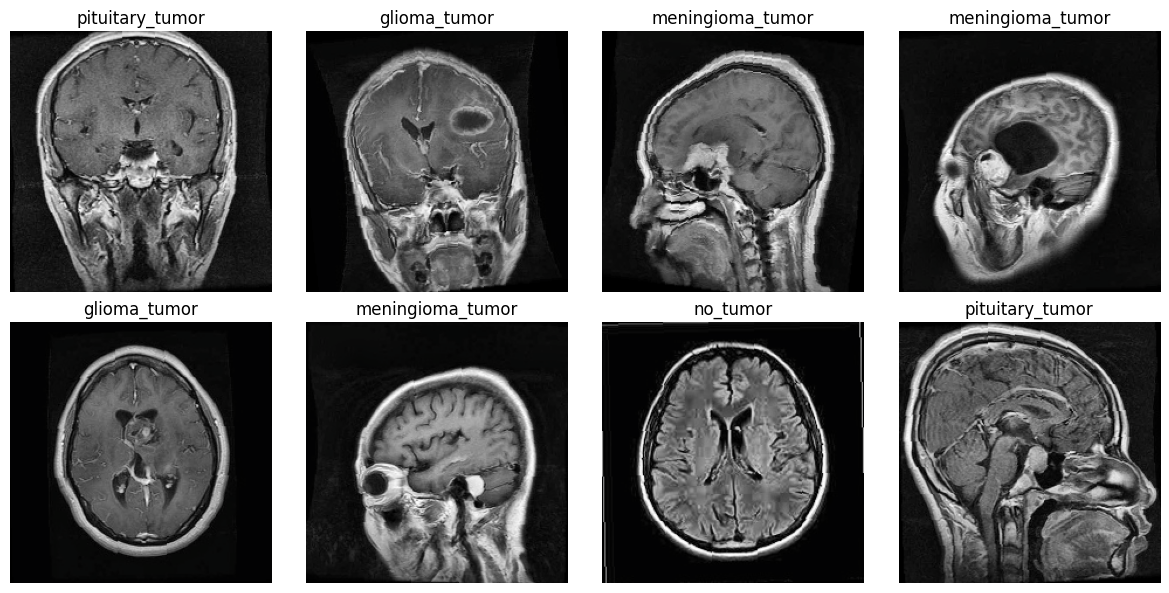

In [4]:
# Show a few sample images from the training dataset
def imshow_tensor(img_tensor, ax=None, title=None):
    """
    Displays a tensor as an image on the provided Matplotlib axis.
    Args:
        img_tensor (torch.Tensor): Image tensor to display.
        ax (matplotlib.axes.Axes, optional): Axis to draw the image on. If None uses plt.
        title (str, optional): Title for the image. Defaults to None.
    """

    # ensure tensor is on CPU and convert to numpy
    img = img_tensor.cpu().numpy().transpose((1,2,0)) 
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    if ax is None:
        plt.imshow(img)
        if title: plt.title(title)
        plt.axis('off')
    else:
        ax.imshow(img)
        if title: ax.set_title(title)
        ax.axis('off')


data_iter = iter(train_loader)
images, labels = next(data_iter)
fig, axes = plt.subplots(2,4, figsize=(12,6))
axes_flat = axes.ravel()
n_plots = min(images.size(0), len(axes_flat))
for i in range(n_plots):
    im = images[i]
    lbl = labels[i].item() if hasattr(labels[i], 'item') else int(labels[i])
    class_name = train_ds.classes[lbl]
    imshow_tensor(im, ax=axes_flat[i], title=class_name)
# disable unused axes
for ax in axes_flat[n_plots:]:
    ax.axis('off')
plt.tight_layout()
plt.show()

# Model Selection

- Compare ResNet18 vs ResNet50 vs EfficientNet
- Decide whether to freeze layers initially

In [5]:
import torch.nn as nn
from torchvision import models
from torchvision.models import (
    ResNet18_Weights,
    ResNet50_Weights,
    EfficientNet_B0_Weights,
    MobileNet_V2_Weights,
)

def _replace_head(model, num_classes):
    # handle common architectures' classifier heads
    if hasattr(model, "fc"):
        in_f = model.fc.in_features
        model.fc = nn.Linear(in_f, num_classes)
    elif hasattr(model, "classifier"):
        # classifier may be Sequential([... , Linear]) or nn.Linear
        clf = model.classifier
        if isinstance(clf, nn.Sequential):
            in_f = clf[-1].in_features
            clf[-1] = nn.Linear(in_f, num_classes)
            model.classifier = clf
        elif isinstance(clf, nn.Linear):
            in_f = clf.in_features
            model.classifier = nn.Linear(in_f, num_classes)
        else:
            raise RuntimeError("Unexpected classifier module structure")
    else:
        raise RuntimeError("Unknown model head to replace")
    return model

def get_model(name: str, num_classes: int, pretrained: bool = True, freeze_backbone: bool = True, device=torch.device("cpu")):
    name = name.lower()
    if name == "resnet18":
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
    elif name == "resnet50":
        weights = ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)
    elif name == "efficientnet_b0":
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)
    elif name == "mobilenet_v2":
        weights = MobileNet_V2_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v2(weights=weights)
    else:
        raise ValueError(f"Unsupported model: {name}")

    model = _replace_head(model, num_classes)

    if freeze_backbone:
        for n, p in model.named_parameters():
            if "fc" in n or "classifier" in n:
                p.requires_grad = True
            else:
                p.requires_grad = False

    model = model.to(device)
    # quick summary
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model: {name}  total_params={total:,}  trainable_params={trainable:,}  device={device}")
    return model

# usage example
num_classes = len(train_ds.classes)
model = get_model("resnet18", num_classes, pretrained=True, freeze_backbone=True, device=device)

Model: resnet18  total_params=11,178,564  trainable_params=2,052  device=cpu


# Class Imbalances

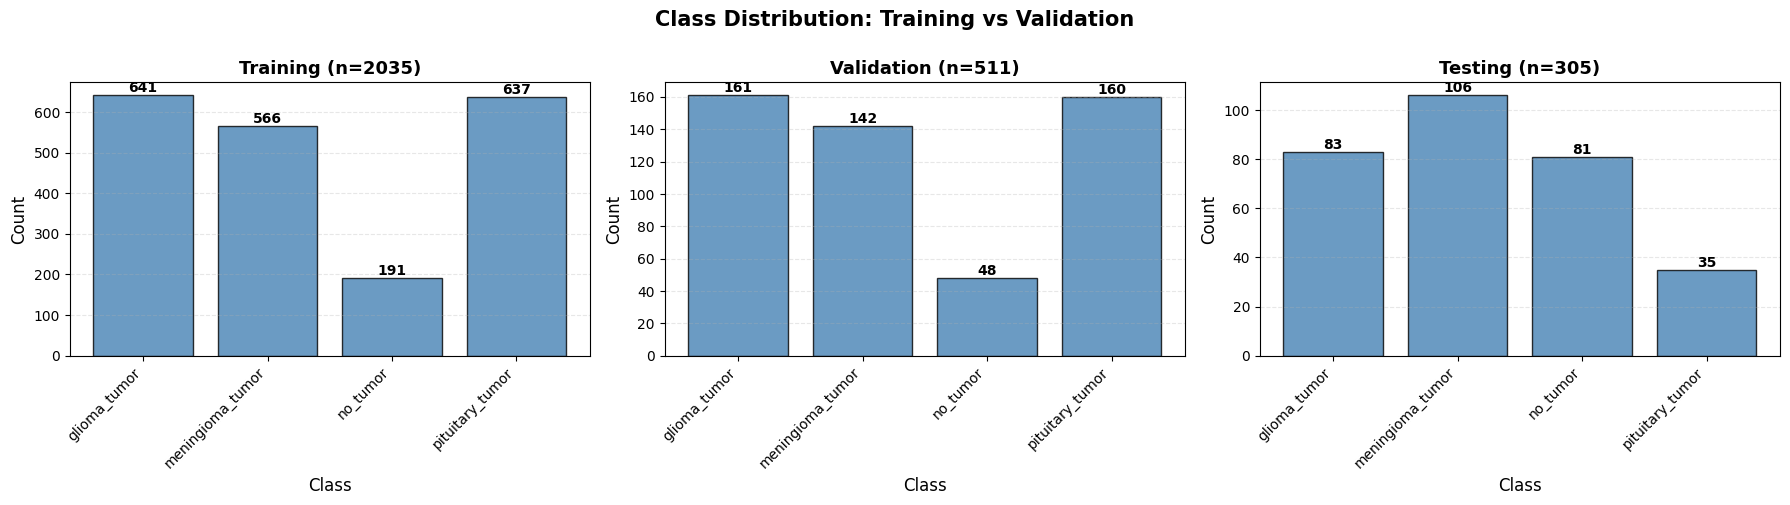


CLASS IMBALANCE SUMMARY

Training:
  Total samples: 2035
  glioma_tumor: 641 (31.5%)
  meningioma_tumor: 566 (27.8%)
  no_tumor: 191 (9.4%)
  pituitary_tumor: 637 (31.3%)
  Imbalance ratio (max/min): 3.36x

Validation:
  Total samples: 511
  glioma_tumor: 161 (31.5%)
  meningioma_tumor: 142 (27.8%)
  no_tumor: 48 (9.4%)
  pituitary_tumor: 160 (31.3%)
  Imbalance ratio (max/min): 3.35x

Testing:
  Total samples: 305
  glioma_tumor: 83 (27.2%)
  meningioma_tumor: 106 (34.8%)
  no_tumor: 81 (26.6%)
  pituitary_tumor: 35 (11.5%)
  Imbalance ratio (max/min): 3.03x


In [6]:
# Visualize class distribution across train/val splits
def plot_class_distribution(datasets_dict, title="Class Distribution"):
    """
    Plot bar charts showing class counts across multiple datasets.
    Args:
        datasets_dict: dict of {split_name: ImageFolder dataset}
    """
    fig, axes = plt.subplots(1, len(datasets_dict), figsize=(6*len(datasets_dict), 5))
    if len(datasets_dict) == 1:
        axes = [axes]
    
    for ax, (split_name, ds) in zip(axes, datasets_dict.items()):
        labels = np.array(ds.targets)
        class_counts = np.bincount(labels)
        class_names = ds.classes
        
        bars = ax.bar(range(len(class_counts)), class_counts, color='steelblue', edgecolor='black', alpha=0.8)
        ax.set_xticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_ylabel('Count', fontsize=12)
        ax.set_xlabel('Class', fontsize=12)
        ax.set_title(f'{split_name} (n={len(ds)})', fontsize=13, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # annotate bars with counts
        for i, (bar, count) in enumerate(zip(bars, class_counts)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{count}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.suptitle(title, fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    # print imbalance statistics
    print("\n" + "="*60)
    print("CLASS IMBALANCE SUMMARY")
    print("="*60)
    for split_name, ds in datasets_dict.items():
        labels = np.array(ds.targets)
        class_counts = np.bincount(labels)
        class_names = ds.classes
        ratio = class_counts.max() / class_counts.min()
        print(f"\n{split_name}:")
        print(f"  Total samples: {len(ds)}")
        for i, (name, count) in enumerate(zip(class_names, class_counts)):
            pct = 100 * count / len(ds)
            print(f"  {name}: {count} ({pct:.1f}%)")
        print(f"  Imbalance ratio (max/min): {ratio:.2f}x")
    print("="*60)

# visualize train and validation distributions
plot_class_distribution({
    'Training': train_ds,
    'Validation': val_ds,
    'Testing': test_ds
}, title="Class Distribution: Training vs Validation")

# Model Training

# Model Evaluation

# Grad-CAM